Current training data shape: (60000, 1, 28, 28)
Current training labels shape: (60000, 1, 10)
Training data shape: torch.Size([60000, 28, 28])
Training labels shape: torch.Size([60000, 1, 10])


TypeError: Invalid shape (1, 28, 28) for image data

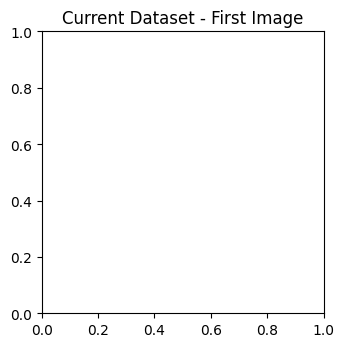

In [ ]:
# Obtain the fmnist dataset and prepare it for training.
import torch
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
import numpy as np
from matplotlib import pyplot as plt

# Import the current dataset (should be similar in shape to MNIST).
current_train_data = np.load('./Datasets/Images/Training_Dataset.npy')
current_train_labels = np.load('./Datasets/Labels/Training_Dataset.npy')

# Print out the shapes to verify.
print(f'Current training data shape: {current_train_data.shape}')        # Should be (60000, 1, 28, 28)
print(f'Current training labels shape: {current_train_labels.shape}')    # Should be (60000, 10)

# Load the Fashion-MNIST dataset with transformations that convert the labels to one-hot encoding.
train_dataset = torchvision.datasets.FashionMNIST(root='./data/', train=True,
                                 transform=torchvision.transforms.ToTensor(),
                                 target_transform=torchvision.transforms.Compose([
                                 lambda x:torch.LongTensor([x]), # or just torch.tensor
                                 lambda x:F.one_hot(x,10)]),
                                 download=True)

test_dataset = torchvision.datasets.FashionMNIST(root='./data/', train=False,
                                 transform=torchvision.transforms.ToTensor(),
                                 target_transform=torchvision.transforms.Compose([
                                 lambda x:torch.LongTensor([x]), # or just torch.tensor
                                 lambda x:F.one_hot(x,10)]),
                                 download=True)

# Get all the training data and labels as tensors.
train_data = train_dataset.data.float() / 255.0  # Normalize to [0, 1]
train_labels = torch.stack([label for _, label in train_dataset])

# Print out the shapes to verify.
print(f'Training data shape: {train_data.shape}')        # Should be (60000, 1, 28, 28)
print(f'Training labels shape: {train_labels.shape}')    # Should be (60000, 1, 10)

# Plot the first element of both datasets to visually verify.
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title('Current Dataset - First Image')
plt.imshow(current_train_data[0], cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Fashion-MNIST - First Image')
plt.imshow(train_data[0], cmap='gray')
plt.axis('off')
plt.show()